In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [3]:
from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw"

# Load datasets
customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH / "olist_geolocation_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.shape

(99441, 8)

In [6]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [7]:
orders["order_status"].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
dataset_summary = pd.DataFrame({
    "Dataset": [
        "Customers",
        "Geolocation",
        "Orders",
        "Order Items",
        "Payments",
        "Reviews",
        "Products",
        "Sellers",
        "Category Translation"
    ],
    "Rows": [
        len(customers),
        len(geolocation),
        len(orders),
        len(order_items),
        len(payments),
        len(reviews),
        len(products),
        len(sellers),
        len(category_translation)
    ],
    "Columns": [
        len(customers.columns),
        len(geolocation.columns),
        len(orders.columns),
        len(order_items.columns),
        len(payments.columns),
        len(reviews.columns),
        len(products.columns),
        len(sellers.columns),
        len(category_translation.columns)
    ]
})

dataset_summary

,Dataset,Rows,Columns
0,Customers,99441,5
1,Geolocation,1000163,5
2,Orders,99441,8
3,Order Items,112650,7
4,Payments,103886,5
5,Reviews,99224,7
6,Products,32951,9
7,Sellers,3095,4
8,Category Translation,71,2


In [9]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [11]:
customers["customer_id"].nunique()

99441

In [12]:
customers["customer_unique_id"].nunique()

96096

In [13]:
orders["customer_id"].value_counts().head(10)

customer_id
9ef432eb6251297304e76186b10a928d    1
b0830fb4747a6c6d20dea0b8c802d7ef    1
41ce2a54c0b03bf3443c3d931a367089    1
f88197465ea7920adcdbec7375364d82    1
8ab97904e6daea8866dbdbc4fb7aad2c    1
503740e9ca751ccdda7ba28e9ab8f608    1
ed0271e0b7da060a393796590e7b737a    1
9bdf08b4b3b52b5526ff42d37d47f222    1
f54a9f0e6b351c431402b8461ea51999    1
31ad1d1b63eb9962463f764d4e6e0c9d    1
Name: count, dtype: int64

In [14]:
customer_order_counts = orders["customer_id"].value_counts()

customer_order_counts.value_counts().sort_index()

count
1    99441
Name: count, dtype: int64

In [15]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [16]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [17]:
items_per_order = order_items.groupby("order_id")["order_item_id"].count()

items_per_order.value_counts().sort_index()

order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64

In [18]:
# Check missing values in the orders dataset

orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [19]:
total_product_revenue = order_items["price"].sum()

total_freight = order_items["freight_value"].sum()

print(f"Total product revenue: R$ {total_product_revenue:,.2f}")
print(f"Total freight value: R$ {total_freight:,.2f}")

Total product revenue: R$ 13,591,643.70
Total freight value: R$ 2,251,909.54


In [20]:
total_order_item_value = (
    order_items["price"] + order_items["freight_value"]
).sum()

print(f"Total product + freight value: R$ {total_order_item_value:,.2f}")

Total product + freight value: R$ 15,843,553.24


In [21]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [22]:
orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [23]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [24]:
orders[orders["order_approved_at"].isnull()]["order_status"].value_counts()


order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [25]:
orders[orders["order_delivered_carrier_date"].isnull()]["order_status"].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [26]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [27]:
orders["order_purchase_timestamp"].dtype

dtype('<M8[us]')

In [28]:
date_columns = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [29]:
orders[[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [30]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [31]:
orders[[
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "delivery_days"
]].head(10)

,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0
5,delivered,2017-07-09 21:57:05,2017-07-26 10:57:55,16.0
6,invoiced,2017-04-11 12:22:08,NaT,NaN
7,delivered,2017-05-16 13:10:30,2017-05-26 12:55:51,9.0
8,delivered,2017-01-23 18:29:09,2017-02-02 14:08:10,9.0
9,delivered,2017-07-29 11:55:02,2017-08-16 17:14:30,18.0


In [32]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [33]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [34]:
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

In [35]:
orders["delivery_performance"] = np.where(
    orders["delivery_delay_days"] < 0,
    "Early",
    np.where(
        orders["delivery_delay_days"] == 0,
        "On Time",
        "Late"
    )
)

orders["delivery_performance"].value_counts()

delivery_performance
Early      88649
Late        9500
On Time     1292
Name: count, dtype: int64

In [36]:
orders["delivery_performance"] = np.select(
    [
        orders["delivery_delay_days"].isna(),
        orders["delivery_delay_days"] < 0,
        orders["delivery_delay_days"] == 0,
        orders["delivery_delay_days"] > 0
    ],
    [
        "Unknown",
        "Early",
        "On Time",
        "Late"
    ]
)

orders["delivery_performance"].value_counts()

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

In [37]:
orders["delivery_performance"] = np.select(
    [
        orders["delivery_delay_days"].isna(),
        orders["delivery_delay_days"] < 0,
        orders["delivery_delay_days"] == 0,
        orders["delivery_delay_days"] > 0
    ],
    [
        "Unknown",
        "Early",
        "On Time",
        "Late"
    ],
    default="Unknown"
)

orders["delivery_performance"].value_counts()

delivery_performance
Early      88649
Late        6535
Unknown     2965
On Time     1292
Name: count, dtype: int64

In [38]:
delivery_performance_pct = (
    orders["delivery_performance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

delivery_performance_pct

delivery_performance
Early      89.15
Late        6.57
Unknown     2.98
On Time     1.30
Name: proportion, dtype: float64

In [39]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders["purchase_month"].value_counts().sort_index() # sort index to see the months in chronological order

purchase_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

In [40]:
orders[
    (orders["purchase_month"] < "2017-01") |
    (orders["purchase_month"] > "2018-08")
][
    ["order_id", "order_purchase_timestamp", "order_status"]
].head(20)

,order_id,order_purchase_timestamp,order_status
324,d3c8851a6651eeff2f73b0e011ac45d0,2016-10-05 22:44:13,processing
378,cbbb524a0e1646aa6cf7a3c0bbe517ad,2016-10-05 07:31:49,delivered
699,ac2b7c522d811acba0aa270ed3e112e4,2016-10-05 15:08:00,delivered
1384,7033745709b7cf1bac7d2533663592de,2016-10-04 14:13:22,delivered
1449,5cd498954e2b37d71b315166809b4bd7,2016-10-07 00:54:40,delivered
1801,ed3efbd3a87bea76c2812c66a0b32219,2018-09-20 13:54:16,canceled
2335,dc5f6cd4492bbffe5bcda9b87856c9a5,2016-10-05 13:12:43,delivered
3056,ddaec6fff982b13e7e048b627a11d6da,2016-10-04 19:41:32,canceled
3120,cb2b577a4ebd84bf84ff3990084d490f,2016-10-05 17:11:49,delivered
3801,3b2ca3293a7ce539ea2379d704fa37ce,2016-10-05 12:44:09,delivered


In [41]:
monthly_orders = orders.groupby("purchase_month").size()

monthly_orders

purchase_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

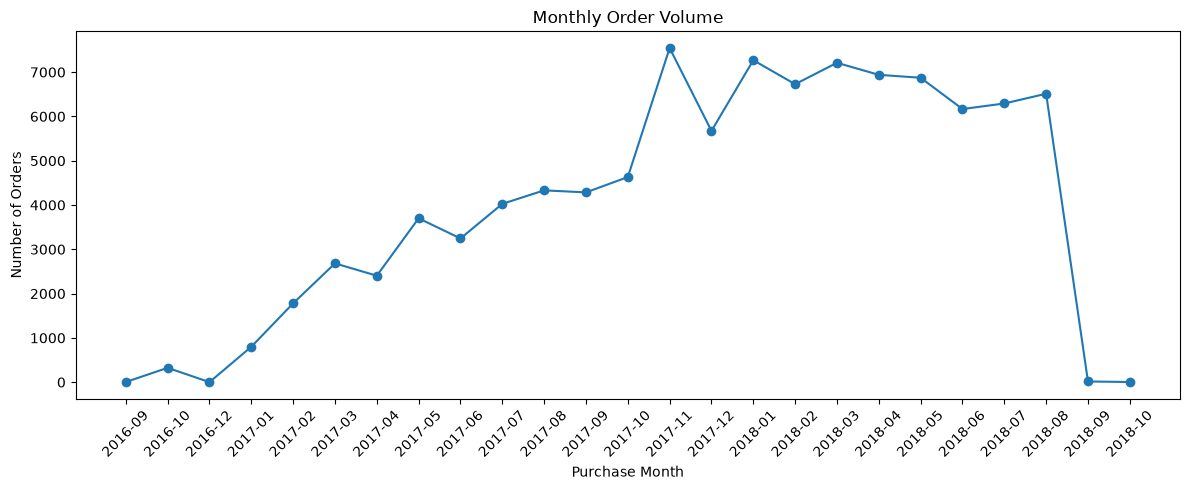

In [42]:
monthly_orders = orders.groupby("purchase_month").size()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# Payment Method Analysis

payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [44]:
payment_type_pct = (
    payments["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

payment_type_pct

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: proportion, dtype: float64

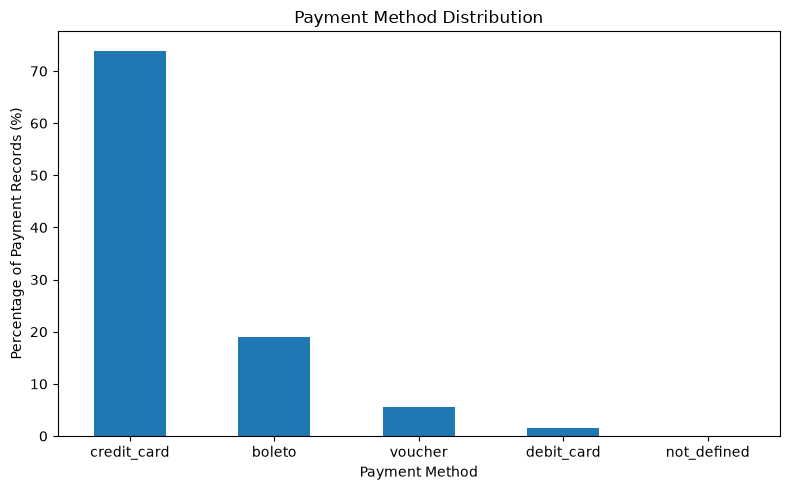

In [45]:
plt.figure(figsize=(8, 5))

payment_type_pct.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Payment Records (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
payment_value_by_type = (
    payments.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_value_by_type

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

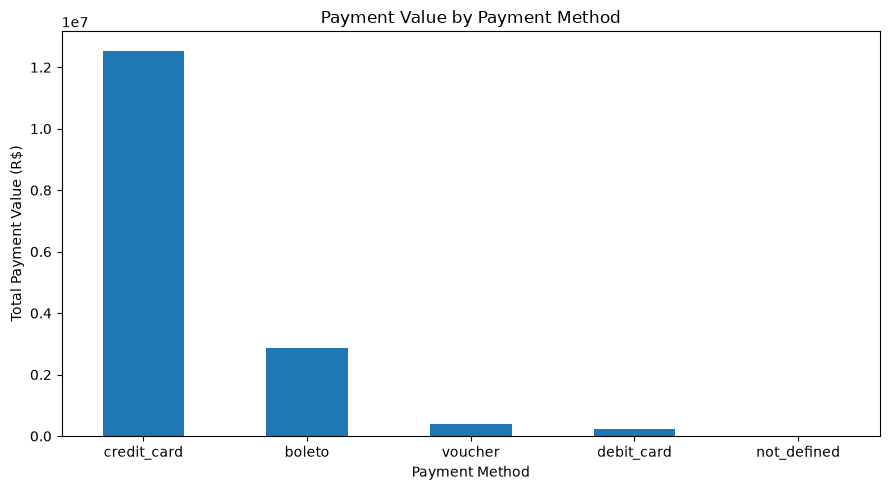

In [47]:
plt.figure(figsize=(9, 5))

payment_value_by_type.plot(kind="bar")

plt.title("Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Payment Value (R$)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
payments["payment_installments"].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [49]:
installment_pct = (
    payments["payment_installments"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

installment_pct

payment_installments
0      0.00
1     50.58
2     11.95
3     10.07
4      6.83
5      5.04
6      3.77
7      1.57
8      4.11
9      0.62
10     5.13
11     0.02
12     0.13
13     0.02
14     0.01
15     0.07
16     0.00
17     0.01
18     0.03
20     0.02
21     0.00
22     0.00
23     0.00
24     0.02
Name: proportion, dtype: float64

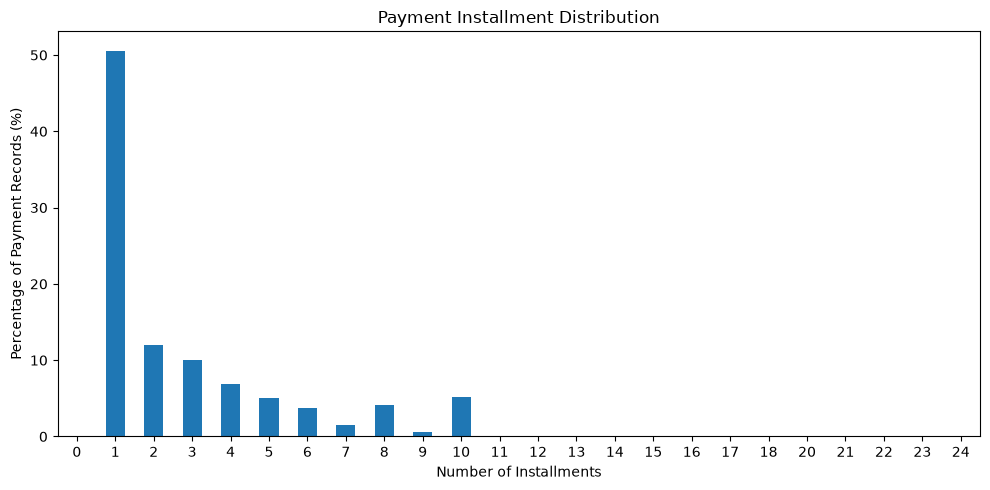

In [50]:
plt.figure(figsize=(10, 5))

installment_pct.plot(kind="bar")

plt.title("Payment Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Percentage of Payment Records (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
# Customer Review Analysis

reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [52]:
review_score_pct = (
    reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

review_score_pct

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64

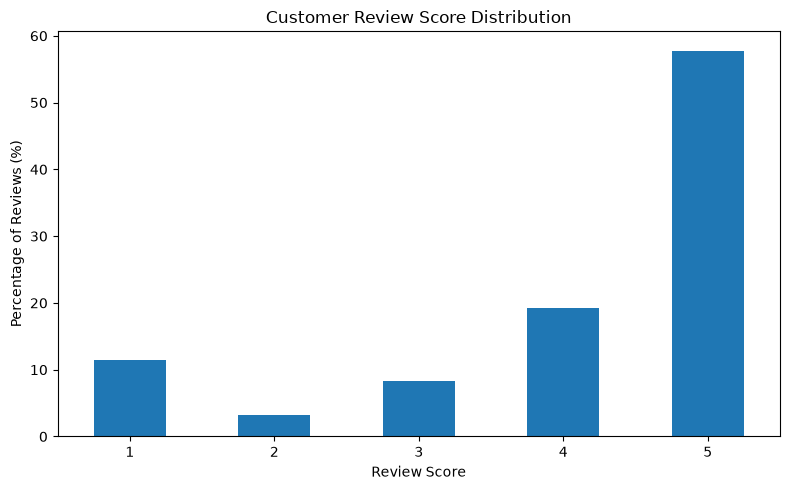

In [53]:
plt.figure(figsize=(8, 5))

review_score_pct.plot(kind="bar")

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Percentage of Reviews (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
average_review_score = reviews["review_score"].mean()

print(f"Average review score: {average_review_score:.2f}")

Average review score: 4.09


In [55]:
reviews["review_comment_message"].isnull().sum()

np.int64(58247)

In [56]:
review_comment_pct = (
    reviews["review_comment_message"]
    .notna()
    .mean()
    * 100
)

print(f"Reviews with written comments: {review_comment_pct:.2f}%")

Reviews with written comments: 41.30%


In [57]:
reviews["order_id"].nunique()

98673

In [58]:
reviews_per_order = (
    reviews.groupby("order_id")
    .size()
    .value_counts()
    .sort_index()
)

reviews_per_order

1    98126
2      543
3        4
Name: count, dtype: int64

In [59]:
review_score_by_order = (
    reviews.groupby("order_id")["review_score"]
    .mean()
    .reset_index()
)

review_score_by_order.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [60]:
orders_with_reviews = orders.merge(
    review_score_by_order,
    on="order_id",
    how="inner"
)

orders_with_reviews[
    ["order_id", "delivery_performance", "delivery_delay_days", "review_score"]
].head()

,order_id,delivery_performance,delivery_delay_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,Early,-8.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,Early,-6.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,Early,-18.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,Early,-13.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,Early,-10.0,5.0


In [61]:
average_review_by_delivery = (
    orders_with_reviews
    .groupby("delivery_performance")["review_score"]
    .mean()
    .round(2)
)

average_review_by_delivery

delivery_performance
Early      4.29
Late       2.27
On Time    4.04
Unknown    1.75
Name: review_score, dtype: float64

In [62]:
review_delivery_counts = (
    orders_with_reviews["delivery_performance"]
    .value_counts()
)

review_delivery_counts

delivery_performance
Early      88168
Late        6382
Unknown     2843
On Time     1280
Name: count, dtype: int64

In [63]:
review_delivery_pct = (
    orders_with_reviews["delivery_performance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

review_delivery_pct

delivery_performance
Early      89.35
Late        6.47
Unknown     2.88
On Time     1.30
Name: proportion, dtype: float64

In [64]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [65]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [66]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [67]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [68]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [69]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products[
    ["product_id", "product_category_name", "product_category_name_english"]
].head()

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


In [70]:
order_items_with_products = order_items.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

order_items_with_products[
    ["order_id", "product_id", "price", "freight_value",
     "product_category_name_english"]
].head()

,order_id,product_id,price,freight_value,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,18.14,garden_tools


In [71]:
category_revenue = (
    order_items_with_products
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

In [72]:
category_units = (
    order_items_with_products
    .groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
)

category_units.head(10)

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
dtype: int64

In [73]:
category_average_price = (
    order_items_with_products
    .groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
)

category_average_price.head(10)

product_category_name_english
computers                                1098.340542
small_appliances_home_oven_and_coffee     624.285658
home_appliances_2                         476.124958
agro_industry_and_commerce                342.124858
musical_instruments                       281.616000
small_appliances                          280.778468
fixed_telephony                           225.693182
construction_tools_safety                 208.992371
watches_gifts                             201.135984
air_conditioning                          185.269226
Name: price, dtype: float64

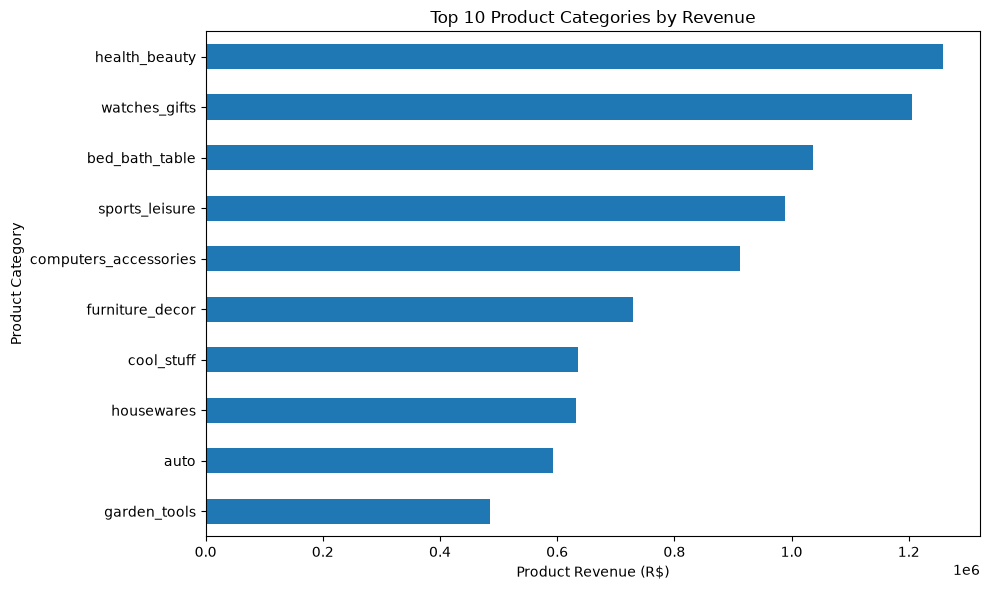

In [74]:
top_categories_revenue = category_revenue.head(10)

plt.figure(figsize=(10, 6))

top_categories_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Revenue (R$)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

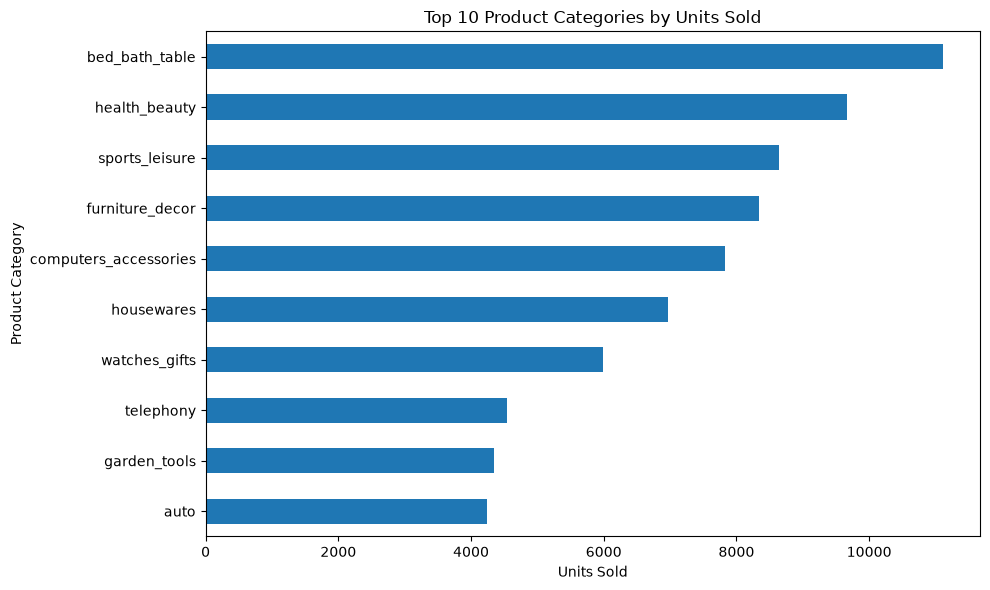

In [75]:
top_categories_units = category_units.head(10)

plt.figure(figsize=(10, 6))

top_categories_units.sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [76]:
category_revenue_pct = (
    category_revenue
    .div(category_revenue.sum())
    .mul(100)
    .round(2)
)

category_revenue_pct.head(10)

product_category_name_english
health_beauty            9.39
watches_gifts            8.99
bed_bath_table           7.73
sports_leisure           7.37
computers_accessories    6.80
furniture_decor          5.44
cool_stuff               4.74
housewares               4.72
auto                     4.42
garden_tools             3.62
Name: price, dtype: float64

In [77]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [78]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [79]:
order_items_with_sellers = order_items.merge(
    sellers,
    on="seller_id",
    how="left"
)

order_items_with_sellers.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [80]:
unique_sellers = order_items_with_sellers["seller_id"].nunique()

print(f"Unique sellers with sales: {unique_sellers}")

Unique sellers with sales: 3095


In [81]:
seller_sales = (
    order_items_with_sellers
    .groupby("seller_id")
    .agg(
        units_sold=("order_item_id", "count"),
        product_revenue=("price", "sum")
    )
    .sort_values("product_revenue", ascending=False)
)

seller_sales.head(10)

,units_sold,product_revenue
seller_id,,
4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63
53243585a1d6dc2643021fd1853d8905,410,222776.05
4a3ca9315b744ce9f8e9374361493884,1987,200472.92
fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03
7c67e1448b00f6e969d365cea6b010ab,1364,187923.89
7e93a43ef30c4f03f38b393420bc753a,340,176431.87
da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57
7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53
1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55


In [82]:
seller_sales["average_item_price"] = (
    seller_sales["product_revenue"] / seller_sales["units_sold"]
)

seller_sales.head(10)

,units_sold,product_revenue,average_item_price
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63,198.505735
53243585a1d6dc2643021fd1853d8905,410,222776.05,543.356220
4a3ca9315b744ce9f8e9374361493884,1987,200472.92,100.892260
fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03,331.129744
7c67e1448b00f6e969d365cea6b010ab,1364,187923.89,137.774113
7e93a43ef30c4f03f38b393420bc753a,340,176431.87,518.917265
da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57,103.311779
7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53,121.046567
1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55,97.316912


In [83]:
seller_locations = (
    order_items_with_sellers[
        ["seller_id", "seller_city", "seller_state"]
    ]
    .drop_duplicates("seller_id")
)

In [84]:
seller_locations.head()

,seller_id,seller_city,seller_state
0,48436dade18ac8b2bce089ec2a041202,volta redonda,SP
1,dd7ddc04e1b6c2c614352b383efe2d36,sao paulo,SP
2,5b51032eddd242adc84c38acab88f23d,borda da mata,MG
3,9d7a1d34a5052409006425275ba1c2b4,franca,SP
4,df560393f3a51e74553ab94004ba5c87,loanda,PR


In [85]:
seller_sales = seller_sales.merge(
    seller_locations,
    on="seller_id",
    how="left"
)

In [86]:
seller_sales.head(10)

,seller_id,units_sold,product_revenue,average_item_price,seller_city,seller_state
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,229472.63,198.505735,guariba,SP
1,53243585a1d6dc2643021fd1853d8905,410,222776.05,543.356220,lauro de freitas,BA
2,4a3ca9315b744ce9f8e9374361493884,1987,200472.92,100.892260,ibitinga,SP
3,fa1c13f2614d7b5c4749cbc52fecda94,586,194042.03,331.129744,sumare,SP
4,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89,137.774113,itaquaquecetuba,SP
5,7e93a43ef30c4f03f38b393420bc753a,340,176431.87,518.917265,barueri,SP
6,da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57,103.311779,piracicaba,SP
7,7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53,121.046567,sao paulo,SP
8,1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55,97.316912,sao paulo,SP
9,955fee9216a65b617aa5c0531780ce60,1499,135171.70,90.174583,sao paulo,SP


In [87]:
seller_sales = seller_sales.drop(
    columns=["seller_city_y", "seller_state_y"]
)

seller_sales = seller_sales.rename(
    columns={
        "seller_city_x": "seller_city",
        "seller_state_x": "seller_state"
    }
)

KeyError: "['seller_city_y', 'seller_state_y'] not found in axis"

In [88]:
seller_count_by_state = (
    seller_sales
    .groupby("seller_state")
    .size()
    .sort_values(ascending=False)
)

seller_count_by_state

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AM       1
AC       1
PI       1
MA       1
PA       1
dtype: int64

In [89]:
seller_percentage_by_state = (
    seller_count_by_state
    .div(seller_count_by_state.sum())
    .mul(100)
    .round(2)
)

seller_percentage_by_state

seller_state
SP    59.74
PR    11.28
MG     7.88
SC     6.14
RJ     5.53
RS     4.17
GO     1.29
DF     0.97
ES     0.74
BA     0.61
CE     0.42
PE     0.29
PB     0.19
MS     0.16
RN     0.16
MT     0.13
RO     0.06
SE     0.06
AM     0.03
AC     0.03
PI     0.03
MA     0.03
PA     0.03
dtype: float64

In [90]:
state_sales = (
    seller_sales
    .groupby("seller_state")
    .agg(
        sellers=("seller_id", "nunique"),
        units_sold=("units_sold", "sum"),
        product_revenue=("product_revenue", "sum")
    )
)
state_sales

,sellers,units_sold,product_revenue
seller_state,,,
AC,1,1,267.00
AM,1,3,1177.00
BA,19,643,285561.56
CE,13,94,20240.64
DF,30,899,97749.48
ES,23,372,47689.61
GO,40,520,66399.21
MA,1,405,36408.95
MG,244,8827,1011564.74


In [91]:
state_sales["revenue_per_seller"] = (
    state_sales["product_revenue"] / state_sales["sellers"]
)

In [92]:
state_sales.sort_values(
    "revenue_per_seller",
    ascending=False
)

,sellers,units_sold,product_revenue,revenue_per_seller
seller_state,,,,
MA,1,405,36408.95,36408.950000
BA,19,643,285561.56,15029.555789
PE,9,448,91493.85,10165.983333
RJ,171,4818,843984.22,4935.580234
SP,1849,80342,8753396.21,4734.124505
MT,4,145,17070.72,4267.680000
MG,244,8827,1011564.74,4145.757131
PR,349,8671,1261887.21,3615.722665
SC,190,4075,632426.07,3328.558263


In [93]:
state_sales["revenue_per_unit"] = (
    state_sales["product_revenue"] / state_sales["units_sold"]
)

state_sales.sort_values(
    "revenue_per_unit",
    ascending=False
)

,sellers,units_sold,product_revenue,revenue_per_seller,revenue_per_unit
seller_state,,,,,
PB,6,38,17095.00,2849.166667,449.868421
BA,19,643,285561.56,15029.555789,444.108180
AM,1,3,1177.00,1177.000000,392.333333
RO,2,14,4762.20,2381.100000,340.157143
AC,1,1,267.00,267.000000,267.000000
CE,13,94,20240.64,1556.972308,215.325957
PI,1,12,2522.00,2522.000000,210.166667
PE,9,448,91493.85,10165.983333,204.227344
RN,5,56,9992.60,1998.520000,178.439286


In [94]:
top_10_seller_revenue = (
    seller_sales
    .sort_values("product_revenue", ascending=False)
    .head(10)["product_revenue"]
    .sum()
)

total_seller_revenue = seller_sales["product_revenue"].sum()

top_10_revenue_share = (
    top_10_seller_revenue / total_seller_revenue * 100
)

print(f"Top 10 sellers revenue: R${top_10_seller_revenue:,.2f}")
print(f"Total seller revenue: R${total_seller_revenue:,.2f}")
print(f"Top 10 seller revenue share: {top_10_revenue_share:.2f}%")

Top 10 sellers revenue: R$1,787,241.74
Total seller revenue: R$13,591,643.70
Top 10 seller revenue share: 13.15%


In [95]:
customer_order_counts = (
    orders
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

customer_order_counts.describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_id, dtype: float64

In [96]:
customer_type = customer_order_counts.apply(
    lambda x: "Repeat Customer" if x > 1 else "One-Time Customer"
)

customer_type.value_counts()

order_id
One-Time Customer    93099
Repeat Customer       2997
Name: count, dtype: int64

In [97]:
repeat_customer_rate = (
    (customer_type == "Repeat Customer").sum()
    / len(customer_type)
    * 100
)

print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")

Repeat customer rate: 3.12%


In [98]:
repeat_customer_orders = customer_order_counts[
    customer_order_counts > 1
]

repeat_customer_orders.value_counts().sort_index()

order_id
2     2745
3      203
4       30
5        8
6        6
7        3
9        1
17       1
Name: count, dtype: int64

In [99]:
two_order_customer_share = (
    (repeat_customer_orders == 2).sum()
    / len(repeat_customer_orders)
    * 100
)

print(
    f"Repeat customers with exactly 2 orders: "
    f"{two_order_customer_share:.2f}%"
)

Repeat customers with exactly 2 orders: 91.59%


In [100]:
orders_with_customers = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

orders_with_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,delivery_performance,purchase_month,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,Early,2017-10,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,Early,2018-07,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,Early,2018-08,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,Early,2017-11,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,Early,2018-02,72632f0f9dd73dfee390c9b22eb56dd6


In [101]:
order_items_with_customers = order_items.merge(
    orders_with_customers[
        ["order_id", "customer_unique_id"]
    ],
    on="order_id",
    how="left"
)

order_items_with_customers.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,871766c5855e863f6eccc05f988b23cb
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,eb28e67c4c0b83846050ddfb8a35d051
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,3818d81c6709e39d06b2738a8d3a2474
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,af861d436cfc08b2c2ddefd0ba074622
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,64b576fb70d441e8f1b2d7d446e483c5


In [102]:
customer_revenue = (
    order_items_with_customers
    .groupby("customer_unique_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13440.0
da122df9eeddfedc1dc1f5349a1a690c     7388.0
763c8b1c9c68a0229c42c9fc6f662b93     7160.0
dc4802a71eae9be1dd28f5d788ceb526     6735.0
459bef486812aa25204be022145caa62     6729.0
ff4159b92c40ebe40454e3e6a7c35ed6     6499.0
4007669dec559734d6f53e029e360987     5934.6
eebb5dda148d3893cdaf5b5ca3040ccb     4690.0
5d0a2980b292d049061542014e8960bf     4599.9
48e1ac109decbb87765a3eade6854098     4590.0
Name: price, dtype: float64

In [103]:
customer_analysis = pd.DataFrame({
    "order_count": customer_order_counts,
    "product_revenue": customer_revenue
})

customer_analysis.head(10)

,order_count,product_revenue
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90
0000f46a3911fa3c0805444483337064,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,1,25.99
0004aac84e0df4da2b147fca70cf8255,1,180.00
0004bd2a26a76fe21f786e4fbd80607f,1,154.00
00050ab1314c0e55a6ca13cf7181fecf,1,27.99
00053a61a98854899e70ed204dd4bafe,1,382.00
0005e1862207bf6ccc02e4228effd9a0,1,135.00


In [104]:
customer_analysis["customer_type"] = np.where(
    customer_analysis["order_count"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_analysis.head(10)

,order_count,product_revenue,customer_type
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,One-Time Customer
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,One-Time Customer
0000f46a3911fa3c0805444483337064,1,69.00,One-Time Customer
0000f6ccb0745a6a4b88665a16c9f078,1,25.99,One-Time Customer
0004aac84e0df4da2b147fca70cf8255,1,180.00,One-Time Customer
0004bd2a26a76fe21f786e4fbd80607f,1,154.00,One-Time Customer
00050ab1314c0e55a6ca13cf7181fecf,1,27.99,One-Time Customer
00053a61a98854899e70ed204dd4bafe,1,382.00,One-Time Customer
0005e1862207bf6ccc02e4228effd9a0,1,135.00,One-Time Customer


In [105]:
customer_type_summary = (
    customer_analysis
    .groupby("customer_type")
    .agg(
        customers=("order_count", "count"),
        total_revenue=("product_revenue", "sum"),
        average_revenue=("product_revenue", "mean")
    )
)

customer_type_summary

,customers,total_revenue,average_revenue
customer_type,,,
One-Time Customer,93099,12812821.73,138.620395
Repeat Customer,2997,778821.97,260.562720


In [106]:
total_customer_revenue = customer_analysis["product_revenue"].sum()

customer_type_summary["revenue_share"] = (
    customer_type_summary["total_revenue"]
    / total_customer_revenue
    * 100
)

customer_type_summary

,customers,total_revenue,average_revenue,revenue_share
customer_type,,,,
One-Time Customer,93099,12812821.73,138.620395,94.269847
Repeat Customer,2997,778821.97,260.562720,5.730153
